# 02 · Logistic regression: `src/regression/_logistic.py`

Tests for `LogisticRegression` (full-batch GD), `SGDClassifier` (mini-batch SGD), and the helpers in the same module: `StandardScaler`, `train_test_split`, `resample`, the binary metrics, `roc_auc_score`, `classification_report` and `plot_decision_boundary`.

| Data | Source | What it tests |
|---|---|---|
| Breast Cancer Wisconsin (569 × 30) | scikit-learn, bundled | accuracy and agreement with scikit-learn's `LogisticRegression` |
| Linearly separable blobs and moons (2-D) | generated | decision boundaries and probability calibration |
| Imbalanced 90/10 data | generated | the built-in *balanced* class weights, `resample` |
| Banknote Authentication (1 372 × 4) | **online** (UCI id 267) | real-world performance |

> The model is **binary only**: labels must be `0` / `1`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics as skm, preprocessing

from _testkit import SEED, Checks, load_online, timed
from src.regression._logistic import (
    LogisticRegression, SGDClassifier, StandardScaler, train_test_split, resample,
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, plot_decision_boundary,
)

checks = Checks("02 logistic regression")
rng = np.random.default_rng(SEED)

## 1. `train_test_split`

The split should be the right size, keep every sample exactly once, preserve class ratios (it stratifies by default), and be reproducible.

In [2]:
X_bc, y_bc = datasets.load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.25, random_state=SEED)

checks.check("split sizes add up", len(Xtr) + len(Xte) == len(X_bc) and len(ytr) == len(Xtr))
checks.at_most("test fraction ≈ 0.25", abs(len(Xte) / len(X_bc) - 0.25), 0.01)
rows = {tuple(r) for r in np.vstack([Xtr, Xte])}
checks.check("no sample lost or duplicated", len(rows) == len({tuple(r) for r in X_bc}))
checks.at_most("stratified: class-1 rate equal in train / test", abs(ytr.mean() - yte.mean()), 0.01)
again = train_test_split(X_bc, y_bc, test_size=0.25, random_state=SEED)
checks.check("same random_state → same split", np.array_equal(again[1], Xte))
plain = train_test_split(X_bc, y_bc, test_size=0.25, random_state=SEED, stratify=None)
checks.check("stratify=None also works", len(plain[1]) + len(plain[0]) == len(X_bc))

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
checks.close("StandardScaler == sklearn", Xtr_s, preprocessing.StandardScaler().fit_transform(Xtr), atol=1e-10)

✅ split sizes add up
✅ test fraction ≈ 0.25  (0.0004 ≤ 0.01)
✅ no sample lost or duplicated
✅ stratified: class-1 rate equal in train / test  (0.0009 ≤ 0.01)
✅ same random_state → same split
✅ stratify=None also works
✅ StandardScaler == sklearn  (max |Δ| = 0.00e+00)


True

## 2. Breast Cancer: accuracy and agreement with scikit-learn

Our model always uses L2 (`λ = 0.1`) and balanced class weights, so the reference is `sklearn.linear_model.LogisticRegression(class_weight="balanced")`. We expect similar accuracy and mostly identical predictions, not identical weights.

In [3]:
with timed("LogisticRegression fit"):
    gd = LogisticRegression(learning_rate=0.1, n_iterations=2000).fit(Xtr_s, ytr)
with timed("SGDClassifier fit"):
    sgd = SGDClassifier(learning_rate=0.05, n_iterations=300, batch_size=32).fit(Xtr_s, ytr)
ref = linear_model.LogisticRegression(class_weight="balanced", max_iter=5000).fit(Xtr_s, ytr)

acc = {"ours GD": gd.score(Xte_s, yte), "ours SGD": sgd.score(Xte_s, yte), "sklearn": ref.score(Xte_s, yte)}
print({k: round(v, 4) for k, v in acc.items()})

checks.at_least("GD test accuracy", acc["ours GD"], 0.95)
checks.at_least("SGD test accuracy", acc["ours SGD"], 0.94)
checks.at_most("|GD − sklearn| accuracy", abs(acc["ours GD"] - acc["sklearn"]), 0.03)
checks.at_least("prediction agreement with sklearn", np.mean(gd.predict(Xte_s) == ref.predict(Xte_s)), 0.95)
cos = gd.weights_ @ ref.coef_.ravel() / (np.linalg.norm(gd.weights_) * np.linalg.norm(ref.coef_))
checks.at_least("weight vector points the same way as sklearn (cosine)", float(cos), 0.8)

⏱️ LogisticRegression fit: 0.04s
⏱️ SGDClassifier fit: 0.01s
{'ours GD': np.float64(0.9859), 'ours SGD': np.float64(0.9718), 'sklearn': 0.9859}
✅ GD test accuracy  (0.9859 ≥ 0.95)
✅ SGD test accuracy  (0.9718 ≥ 0.94)
✅ |GD − sklearn| accuracy  (0.0000 ≤ 0.03)
✅ prediction agreement with sklearn  (1.0000 ≥ 0.95)
✅ weight vector points the same way as sklearn (cosine)  (0.9578 ≥ 0.8)


True

### Probabilities and training curves

✅ predict_proba has shape (n, 2)
✅ probability rows sum to 1  (max |Δ| = 0.00e+00)
✅ probabilities lie in [0, 1]
✅ predict == (P(y=1) ≥ 0.5)
✅ coef_ / coefficients / theta alias weights_
✅ GD loss decreased
✅ SGD loss decreased


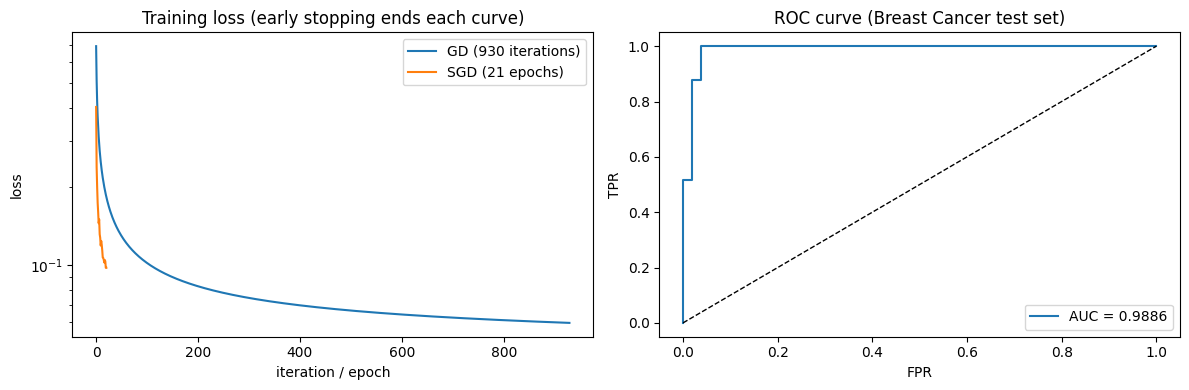

In [4]:
proba = gd.predict_proba(Xte_s)
checks.check("predict_proba has shape (n, 2)", proba.shape == (len(Xte_s), 2))
checks.close("probability rows sum to 1", proba.sum(axis=1), np.ones(len(proba)))
checks.check("probabilities lie in [0, 1]", (proba >= 0).all() and (proba <= 1).all())
checks.check("predict == (P(y=1) ≥ 0.5)", np.array_equal(gd.predict(Xte_s), (proba[:, 1] >= 0.5).astype(int)))
checks.check("coef_ / coefficients / theta alias weights_",
             gd.coef_ is gd.weights_ and gd.coefficients is gd.weights_)
checks.check("GD loss decreased", gd.loss_history_[-1] < gd.loss_history_[0])
checks.check("SGD loss decreased", sgd.loss_history_[-1] < sgd.loss_history_[0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(gd.loss_history_, label=f"GD ({len(gd.loss_history_)} iterations)")
ax[0].plot(sgd.loss_history_, label=f"SGD ({len(sgd.loss_history_)} epochs)")
ax[0].set(title="Training loss (early stopping ends each curve)", xlabel="iteration / epoch", ylabel="loss", yscale="log")
ax[0].legend()
fpr, tpr, _ = skm.roc_curve(yte, proba[:, 1])
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(yte, proba[:, 1]):.4f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set(title="ROC curve (Breast Cancer test set)", xlabel="FPR", ylabel="TPR"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Metrics match scikit-learn

We compare our metrics on the model's predictions and on random labels, which include edge cases.

In [5]:
y_pred = gd.predict(Xte_s)
y_rand_true = rng.integers(0, 2, 200)
y_rand_pred = rng.integers(0, 2, 200)
y_rand_prob = rng.random(200)

for tag, yt, yp in [("model", yte, y_pred), ("random", y_rand_true, y_rand_pred)]:
    checks.check(f"[{tag}] confusion_matrix == sklearn", np.array_equal(confusion_matrix(yt, yp), skm.confusion_matrix(yt, yp)))
    checks.close(f"[{tag}] precision == sklearn", precision_score(yt, yp), skm.precision_score(yt, yp))
    checks.close(f"[{tag}] recall == sklearn", recall_score(yt, yp), skm.recall_score(yt, yp))
    checks.close(f"[{tag}] f1 == sklearn", f1_score(yt, yp), skm.f1_score(yt, yp))

checks.close("roc_auc_score == sklearn (model)", roc_auc_score(yte, proba[:, 1]), skm.roc_auc_score(yte, proba[:, 1]), atol=1e-9)
checks.close("roc_auc_score == sklearn (random)", roc_auc_score(y_rand_true, y_rand_prob), skm.roc_auc_score(y_rand_true, y_rand_prob), atol=1e-9)
checks.close("precision with no positive predictions is 0", precision_score(np.array([1, 0]), np.array([0, 0])), 0.0)

report = classification_report(yte, y_pred, target_names=["malignant", "benign"])
print(report)
checks.check("classification_report names both classes", "malignant" in report and "benign" in report)

✅ [model] confusion_matrix == sklearn
✅ [model] precision == sklearn  (max |Δ| = 0.00e+00)
✅ [model] recall == sklearn  (max |Δ| = 0.00e+00)
✅ [model] f1 == sklearn  (max |Δ| = 1.11e-16)
✅ [random] confusion_matrix == sklearn
✅ [random] precision == sklearn  (max |Δ| = 0.00e+00)
✅ [random] recall == sklearn  (max |Δ| = 0.00e+00)
✅ [random] f1 == sklearn  (max |Δ| = 5.55e-17)
✅ roc_auc_score == sklearn (model)  (max |Δ| = 1.11e-16)
✅ roc_auc_score == sklearn (random)  (max |Δ| = 1.11e-16)
✅ precision with no positive predictions is 0  (max |Δ| = 0.00e+00)
              precision    recall  f1-score   support

     malignant     1.0000    0.9623    0.9808        53
     benign     0.9780    1.0000    0.9889        89

    accuracy                       0.9859        142
   macro avg     0.9890    0.9811    0.9848        142
weighted avg     0.9862    0.9859    0.9859        142
✅ classification_report names both classes


True

## 4. Class imbalance: balanced weights and `resample`

On a 90/10 dataset, an unweighted model is tempted to predict the majority class. Our model's built-in *balanced* weights should give much higher minority-class recall than an unweighted scikit-learn model.

In [6]:
X_imb, y_imb = datasets.make_classification(n_samples=2000, n_features=6, n_informative=4, weights=[0.9, 0.1],
                                            class_sep=0.8, random_state=SEED)
Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_imb, y_imb, test_size=0.3, random_state=SEED)
sc = StandardScaler().fit(Xtr_i)
Xtr_i, Xte_i = sc.transform(Xtr_i), sc.transform(Xte_i)

ours = LogisticRegression(learning_rate=0.1, n_iterations=2000).fit(Xtr_i, ytr_i)
unweighted = linear_model.LogisticRegression().fit(Xtr_i, ytr_i)
rec_ours, rec_unw = recall_score(yte_i, ours.predict(Xte_i)), recall_score(yte_i, unweighted.predict(Xte_i))
print(f"minority recall  ours (balanced): {rec_ours:.3f} | sklearn unweighted: {rec_unw:.3f}")
checks.check("balanced weights raise minority recall", rec_ours > rec_unw + 0.1, f"{rec_ours:.3f} vs {rec_unw:.3f}")

n_min, n_maj = int((ytr_i == 1).sum()), int((ytr_i == 0).sum())
Xd, yd = resample(Xtr_i, ytr_i, strategy="down", random_state=SEED)
Xu, yu = resample(Xtr_i, ytr_i, strategy="up", random_state=SEED)
checks.check("resample('down') → both classes = minority size", np.bincount(yd).tolist() == [n_min, n_min])
checks.check("resample('up') → both classes = majority size", np.bincount(yu).tolist() == [n_maj, n_maj])
checks.check("resample('down') keeps only original rows", {tuple(r) for r in Xd} <= {tuple(r) for r in Xtr_i})
checks.check("resample is reproducible", np.array_equal(resample(Xtr_i, ytr_i, "down", random_state=SEED)[0], Xd))

minority recall  ours (balanced): 0.700 | sklearn unweighted: 0.000
✅ balanced weights raise minority recall  (0.700 vs 0.000)
✅ resample('down') → both classes = minority size
✅ resample('up') → both classes = majority size
✅ resample('down') keeps only original rows
✅ resample is reproducible


True

## 5. Decision boundaries on 2-D data

A linear model separates the blobs almost perfectly but can only draw a straight line through the moons.

✅ separable blobs: training accuracy  (0.9967 ≥ 0.98)


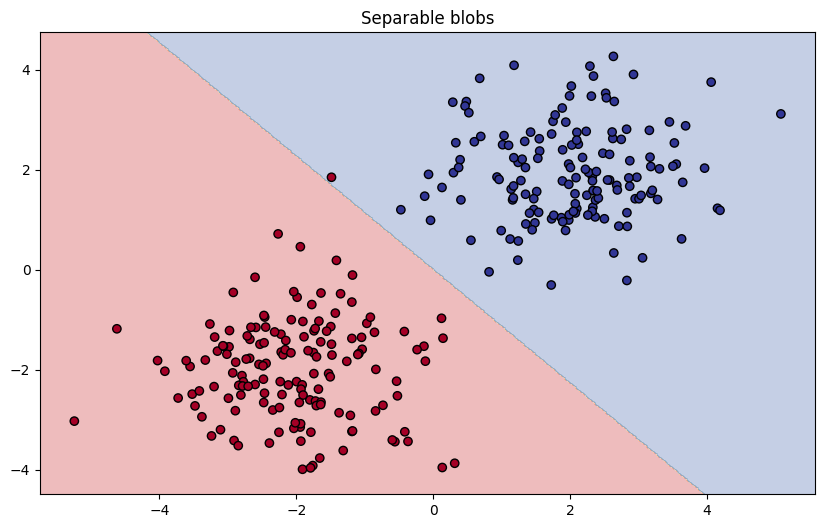

✅ moons: a linear boundary is good but not perfect  (accuracy 0.853)


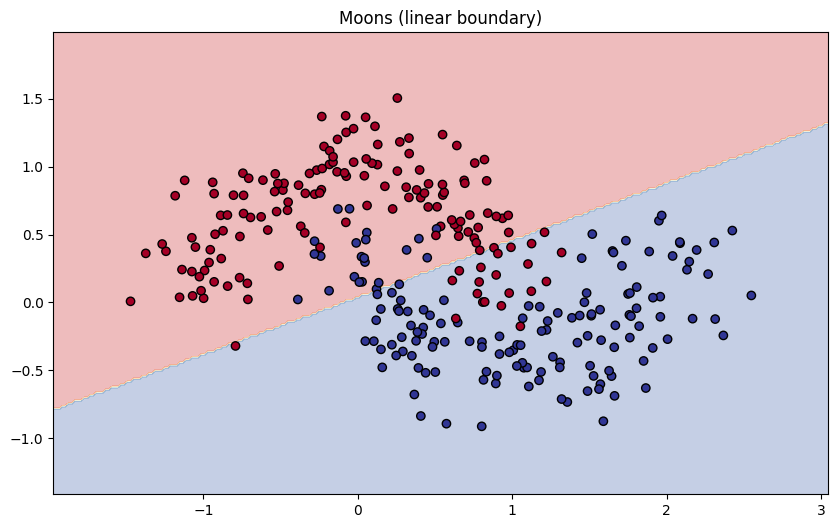

In [7]:
X_blob, y_blob = datasets.make_blobs(n_samples=300, centers=[[-2, -2], [2, 2]], cluster_std=1.0, random_state=SEED)
blob_model = LogisticRegression(learning_rate=0.1, n_iterations=1000).fit(X_blob, y_blob)
checks.at_least("separable blobs: training accuracy", blob_model.score(X_blob, y_blob), 0.98)
plot_decision_boundary(blob_model, X_blob, y_blob, title="Separable blobs")

X_moon, y_moon = datasets.make_moons(n_samples=300, noise=0.2, random_state=SEED)
moon_model = LogisticRegression(learning_rate=0.1, n_iterations=1000).fit(X_moon, y_moon)
checks.check("moons: a linear boundary is good but not perfect", 0.8 <= moon_model.score(X_moon, y_moon) < 0.95,
             f"accuracy {moon_model.score(X_moon, y_moon):.3f}")
plot_decision_boundary(moon_model, X_moon, y_moon, title="Moons (linear boundary)")

## 6. Real data (online): Banknote Authentication

1 372 banknote images described by 4 wavelet features. The classes are almost linearly separable, so expect accuracy above 97 %.

In [8]:
def _banknote():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=267)
    return d.data.features.to_numpy(float), d.data.targets.to_numpy().ravel().astype(int)

bank, online = load_online("Banknote Authentication (UCI 267)", _banknote)
if online:
    Xb, yb = bank
    Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(Xb, yb, test_size=0.25, random_state=SEED)
    sc = StandardScaler().fit(Xtr_b)
    m = LogisticRegression(learning_rate=0.1, n_iterations=2000).fit(sc.transform(Xtr_b), ytr_b)
    acc_b = m.score(sc.transform(Xte_b), yte_b)
    print(classification_report(yte_b, m.predict(sc.transform(Xte_b)), target_names=["genuine", "forged"]))
    checks.at_least("Banknote: test accuracy", acc_b, 0.97)
else:
    checks.skip("Banknote checks", "dataset unavailable offline")

🌐 Banknote Authentication (UCI 267): downloaded / loaded from cache
              precision    recall  f1-score   support

     genuine     1.0000    0.9526    0.9757        190
     forged     0.9441    1.0000    0.9712        152

    accuracy                       0.9737        342
   macro avg     0.9720    0.9763    0.9735        342
weighted avg     0.9752    0.9737    0.9737        342
✅ Banknote: test accuracy  (0.9737 ≥ 0.97)


## 7. API contract and edge cases

In [9]:
m = LogisticRegression()
checks.check("fit() returns self", m.fit(Xtr_s, ytr) is m)
checks.check("SGDClassifier.fit() returns self", (s := SGDClassifier(n_iterations=5)).fit(Xtr_s, ytr) is s)
checks.check("predictions are 0 / 1", set(np.unique(m.predict(Xte_s))) <= {0, 1})
checks.check("score() == accuracy", np.isclose(m.score(Xte_s, yte), np.mean(m.predict(Xte_s) == yte)))
checks.raises("predict before fit raises", Exception, lambda: LogisticRegression().predict(Xte_s))
def _raises_on_multiclass():
    # A binary-only model should refuse labels {0, 1, 2} instead of training on them.
    try:
        LogisticRegression(n_iterations=10).fit(rng.normal(size=(30, 2)), np.repeat([0, 1, 2], 10))
    except ValueError:
        return True
    return False

checks.known_bug("multi-class labels are rejected with a clear error", _raises_on_multiclass,
                 "labels other than 0/1 are accepted silently and predictions are meaningless")

✅ fit() returns self
✅ SGDClassifier.fit() returns self
✅ predictions are 0 / 1
✅ score() == accuracy
✅ predict before fit raises  (ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signatu)
🐞 multi-class labels are rejected with a clear error  (labels other than 0/1 are accepted silently and predictions are meaningless)


False

## Summary

In [10]:
checks.summary()

02 logistic regression: 44 passed, 0 failed, 0 skipped, 1 known bug(s) (45 checks)

Known library bugs (not counted as failures):
  🐞 multi-class labels are rejected with a clear error: labels other than 0/1 are accepted silently and predictions are meaningless


,check,status,detail
0,split sizes add up,pass,
1,test fraction ≈ 0.25,pass,0.0004 ≤ 0.01
2,no sample lost or duplicated,pass,
3,stratified: class-1 rate equal in train / test,pass,0.0009 ≤ 0.01
4,same random_state → same split,pass,
5,stratify=None also works,pass,
6,StandardScaler == sklearn,pass,max |Δ| = 0.00e+00
7,GD test accuracy,pass,0.9859 ≥ 0.95
8,SGD test accuracy,pass,0.9718 ≥ 0.94
9,|GD − sklearn| accuracy,pass,0.0000 ≤ 0.03
